In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

input/
    datasets/
        rx5944/
            amazon-reviews-us-electronics/
                amazon_reviews_us_Electronics_v1_00.tsv


In [2]:
import os
import re
import html
import json
import random
import warnings

import numpy as np
import pandas as pd

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Environment ready.")

Environment ready.


STEP 3 — Locate the TSV automatically

In [3]:
DATA_FILE = None

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file == "amazon_reviews_us_Electronics_v1_00.tsv":
            DATA_FILE = os.path.join(root, file)

if DATA_FILE is None:
    raise FileNotFoundError(
        "amazon_reviews_us_Electronics_v1_00.tsv was not found."
    )

print("Dataset:", DATA_FILE)

Dataset: /kaggle/input/datasets/rx5944/amazon-reviews-us-electronics/amazon_reviews_us_Electronics_v1_00.tsv


STEP 4 — Understand the actual file

In [4]:
df_sample = pd.read_csv(
    DATA_FILE,
    sep="\t",
    nrows=5,
    encoding="utf-8"
)

print(df_sample.columns.tolist())

['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date']


In [5]:
df_sample.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,41409413,R2MTG1GCZLR2DK,B00428R89M,112201306,yoomall 5M Antenna WIFI RP-SMA Female to Male ...,Electronics,5,0,0,N,Y,Five Stars,As described.,2015-08-31
1,US,49668221,R2HBOEM8LE9928,B000068O48,734576678,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor",Electronics,5,0,0,N,Y,It works as advertising.,It works as advertising.,2015-08-31
2,US,12338275,R1P4RW1R9FDPEE,B000GGKOG8,614448099,Channel Master Titan 2 Antenna Preamplifier,Electronics,5,1,1,N,Y,Five Stars,Works pissa,2015-08-31
3,US,38487968,R1EBPM82ENI67M,B000NU4OTA,72265257,LIMTECH Wall charger + USB Hotsync & Charging ...,Electronics,1,0,0,N,Y,One Star,Did not work at all.,2015-08-31
4,US,23732619,R372S58V6D11AT,B00JOQIO6S,308169188,Skullcandy Air Raid Portable Bluetooth Speaker,Electronics,5,1,1,N,Y,Overall pleased with the item,Works well. Bass is somewhat lacking but is pr...,2015-08-31


STEP 5 — Load the dataset

In [6]:
df = pd.read_csv(
    DATA_FILE,
    sep="\t",
    encoding="utf-8",
    on_bad_lines="skip"
)

print("Shape:", df.shape)

Shape: (3091024, 15)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3091024 entries, 0 to 3091023
Data columns (total 15 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   marketplace        object
 1   customer_id        int64 
 2   review_id          object
 3   product_id         object
 4   product_parent     int64 
 5   product_title      object
 6   product_category   object
 7   star_rating        int64 
 8   helpful_votes      int64 
 9   total_votes        int64 
 10  vine               object
 11  verified_purchase  object
 12  review_headline    object
 13  review_body        object
 14  review_date        object
dtypes: int64(5), object(10)
memory usage: 353.7+ MB


In [8]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,41409413,R2MTG1GCZLR2DK,B00428R89M,112201306,yoomall 5M Antenna WIFI RP-SMA Female to Male ...,Electronics,5,0,0,N,Y,Five Stars,As described.,2015-08-31
1,US,49668221,R2HBOEM8LE9928,B000068O48,734576678,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor",Electronics,5,0,0,N,Y,It works as advertising.,It works as advertising.,2015-08-31
2,US,12338275,R1P4RW1R9FDPEE,B000GGKOG8,614448099,Channel Master Titan 2 Antenna Preamplifier,Electronics,5,1,1,N,Y,Five Stars,Works pissa,2015-08-31
3,US,38487968,R1EBPM82ENI67M,B000NU4OTA,72265257,LIMTECH Wall charger + USB Hotsync & Charging ...,Electronics,1,0,0,N,Y,One Star,Did not work at all.,2015-08-31
4,US,23732619,R372S58V6D11AT,B00JOQIO6S,308169188,Skullcandy Air Raid Portable Bluetooth Speaker,Electronics,5,1,1,N,Y,Overall pleased with the item,Works well. Bass is somewhat lacking but is pr...,2015-08-31


STEP 6 — Rename columns

In [9]:
df = df.rename(columns={
    "star_rating": "rating",
    "product_category": "category",
    "review_headline": "review_title",
    "review_body": "review_text"
})

In [10]:
required_columns = [
    "product_id",
    "category",
    "product_title",
    "review_title",
    "review_text",
    "verified_purchase",
    "review_date",
    "rating"
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing columns:", missing)


Missing columns: []


STEP 7 — Keep only the columns we need

In [11]:
df = df[required_columns].copy()

print(df.shape)

(3091024, 8)


STEP 8 — Basic validation

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3091024 entries, 0 to 3091023
Data columns (total 8 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   product_id         object
 1   category           object
 2   product_title      object
 3   review_title       object
 4   review_text        object
 5   verified_purchase  object
 6   review_date        object
 7   rating             int64 
dtypes: int64(1), object(7)
memory usage: 188.7+ MB
None


In [13]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print(missing_values)

review_text          147
review_title          39
review_date           24
product_title          4
product_id             0
category               0
verified_purchase      0
rating                 0
dtype: int64


In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 462


In [15]:
print(df["rating"].value_counts().sort_index())

rating
1     357817
2     179032
3     238387
4     536417
5    1779371
Name: count, dtype: int64


In [16]:
print(
    df["rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

rating
1    11.58
2     5.79
3     7.71
4    17.35
5    57.57
Name: proportion, dtype: float64


STEP 9 — Clean the target

In [17]:
df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

df = df[df["rating"].isin([1, 2, 3, 4, 5])].copy()

df["rating"] = df["rating"].astype(int)

In [18]:
print(df["rating"].value_counts().sort_index())

rating
1     357817
2     179032
3     238387
4     536417
5    1779371
Name: count, dtype: int64


STEP 10 — Remove duplicates

In [19]:
before = len(df)

df = df.drop_duplicates(
    subset=["product_id", "review_title", "review_text"]
)

after = len(df)

print("Removed:", before - after)
print("Remaining:", after)

Removed: 10170
Remaining: 3080854


STEP 11 — Clean text

In [20]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [21]:
df["review_title"] = df["review_title"].fillna("").map(clean_text)
df["review_text"] = df["review_text"].fillna("").map(clean_text)
df["product_title"] = df["product_title"].fillna("").map(clean_text)
df["category"] = df["category"].fillna("").astype(str)

STEP 12 — Combine review title + review body

In [22]:
df["combined_text"] = (
    df["review_title"] + " " + df["review_text"]
).str.strip()

In [23]:
df = df[df["combined_text"].str.len() > 0].copy()

STEP 13 — Add useful numerical features

In [24]:
df["review_char_count"] = df["combined_text"].str.len()

df["review_word_count"] = (
    df["combined_text"]
    .str.split()
    .str.len()
)

df["review_sentence_count"] = (
    df["combined_text"]
    .str.count(r"[.!?]")
)

df["exclamation_count"] = (
    df["combined_text"]
    .str.count("!")
)

df["question_count"] = (
    df["combined_text"]
    .str.count(r"\?")
)

STEP 14 — Verified purchase

In [25]:
df["verified_purchase"] = (
    df["verified_purchase"]
    .astype(str)
    .str.upper()
    .map({
        "Y": 1,
        "N": 0
    })
    .fillna(0)
    .astype(int)
)

STEP 15 — Date features

In [26]:
df["review_date"] = pd.to_datetime(
    df["review_date"],
    errors="coerce"
)

In [27]:
df["review_year"] = df["review_date"].dt.year.fillna(0).astype(int)
df["review_month"] = df["review_date"].dt.month.fillna(0).astype(int)

STEP 16 — EDA

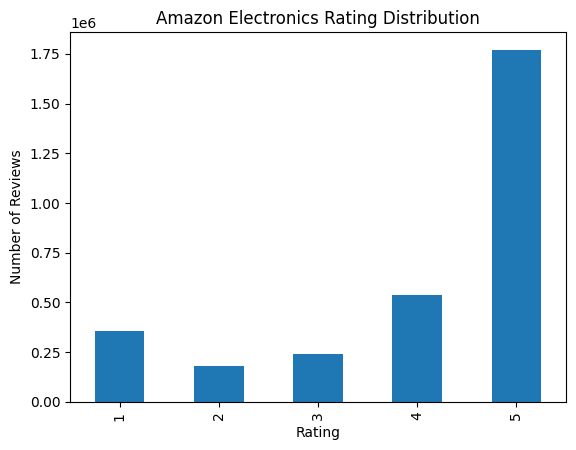

In [28]:
import matplotlib.pyplot as plt

rating_counts = (
    df["rating"]
    .value_counts()
    .sort_index()
)

rating_counts.plot(kind="bar")

plt.title("Amazon Electronics Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [29]:
df[[
    "review_char_count",
    "review_word_count",
    "review_sentence_count"
]].describe()

,review_char_count,review_word_count,review_sentence_count
count,3.080853e+06,3.080853e+06,3.080853e+06
mean,3.950856e+02,7.318459e+01,5.870134e+00
std,6.356028e+02,1.154845e+02,1.000138e+01
min,2.000000e+00,1.000000e+00,0.000000e+00
25%,1.210000e+02,2.300000e+01,2.000000e+00
50%,2.150000e+02,4.000000e+01,4.000000e+00
75%,4.420000e+02,8.300000e+01,7.000000e+00
max,5.280800e+04,9.363000e+03,9.652000e+03


In [30]:
df.groupby("rating")[
    ["review_word_count", "review_char_count"]
].mean()

,review_word_count,review_char_count
rating,,
1,72.099297,387.675822
2,91.900306,495.382431
3,92.470502,496.655338
4,90.444607,487.183613
5,63.692850,344.901984


STEP 17 — Train/test split

In [31]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["rating"],
    random_state=SEED
)

In [32]:
print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (2464682, 16)
Test : (616171, 16)


In [33]:
print("Train distribution:")
print(train_df["rating"].value_counts(normalize=True).sort_index())

print("\nTest distribution:")
print(test_df["rating"].value_counts(normalize=True).sort_index())

Train distribution:
rating
1    0.116083
2    0.058100
3    0.077339
4    0.173873
5    0.574605
Name: proportion, dtype: float64

Test distribution:
rating
1    0.116083
2    0.058099
3    0.077339
4    0.173874
5    0.574605
Name: proportion, dtype: float64


STEP 18 — Define features

In [35]:
TEXT_FEATURE = "combined_text"

In [36]:
NUMERIC_FEATURES = [
    "review_char_count",
    "review_word_count",
    "review_sentence_count",
    "exclamation_count",
    "question_count",
    "verified_purchase",
    "review_year",
    "review_month"
]

In [37]:
CATEGORICAL_FEATURES = [
    "category"
]

STEP 19 — Build the production pipeline

In [38]:
text_pipeline = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=300_000,
    sublinear_tf=True,
    strip_accents="unicode"
)

In [39]:
numeric_pipeline = StandardScaler()

In [40]:
categorical_pipeline = OneHotEncoder(
    handle_unknown="ignore"
)

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            text_pipeline,
            TEXT_FEATURE
        ),
        (
            "numeric",
            numeric_pipeline,
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ]
)

In [42]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    random_state=SEED,
    n_jobs=-1
)

In [43]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

STEP 20 — Train

In [44]:
X_train = train_df[
    [TEXT_FEATURE] +
    NUMERIC_FEATURES +
    CATEGORICAL_FEATURES
]

y_train = train_df["rating"]

X_test = test_df[
    [TEXT_FEATURE] +
    NUMERIC_FEATURES +
    CATEGORICAL_FEATURES
]

y_test = test_df["rating"]

In [45]:
# Check all model input columns for missing values
print("NaN counts:")
print(X_train.isna().sum())

print("\nColumns containing NaN:")
print(X_train.columns[X_train.isna().any()].tolist())

NaN counts:
combined_text            0
review_char_count        0
review_word_count        0
review_sentence_count    0
exclamation_count        0
question_count           0
verified_purchase        0
review_year              0
review_month             0
category                 0
dtype: int64

Columns containing NaN:
[]


In [ ]:
pipeline.fit(X_train, y_train)

STEP 21 — Evaluate using Macro-F1

In [ ]:
y_pred = pipeline.predict(X_test)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Macro-F1: {macro_f1:.4f}")

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5]
)

print(cm)

STEP 22 — Save the production model

In [ ]:
import joblib

os.makedirs("/kaggle/working/artifacts", exist_ok=True)

MODEL_PATH = "/kaggle/working/artifacts/rating_model.joblib"

joblib.dump(
    pipeline,
    MODEL_PATH
)

print("Saved:", MODEL_PATH)

STEP 23 — Save metadata

In [ ]:
metadata = {
    "model_name": "Amazon Electronics Rating Classifier",
    "task": "5-class rating prediction",
    "target": "rating",
    "classes": [1, 2, 3, 4, 5],
    "text_features": [
        "review_title",
        "review_text"
    ],
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "tfidf_ngram_range": [1, 2],
    "tfidf_min_df": 3,
    "tfidf_max_df": 0.95,
    "tfidf_max_features": 300000,
    "class_weight": "balanced",
    "random_state": SEED,
    "metric": "macro_f1",
    "test_macro_f1": float(macro_f1)
}

with open(
    "/kaggle/working/artifacts/metadata.json",
    "w"
) as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved.")

STEP 24 — Test that your saved model actually works

In [ ]:
loaded_model = joblib.load(MODEL_PATH)

In [ ]:
sample = pd.DataFrame({
    "combined_text": [
        "The product works perfectly and I am very happy with the purchase."
    ],
    "review_char_count": [75],
    "review_word_count": [14],
    "review_sentence_count": [1],
    "exclamation_count": [0],
    "question_count": [0],
    "verified_purchase": [1],
    "review_year": [2026],
    "review_month": [9],
    "category": ["Electronics"]
})

In [ ]:
prediction = loaded_model.predict(sample)

print("Predicted rating:", prediction[0])